monobert_msmarco


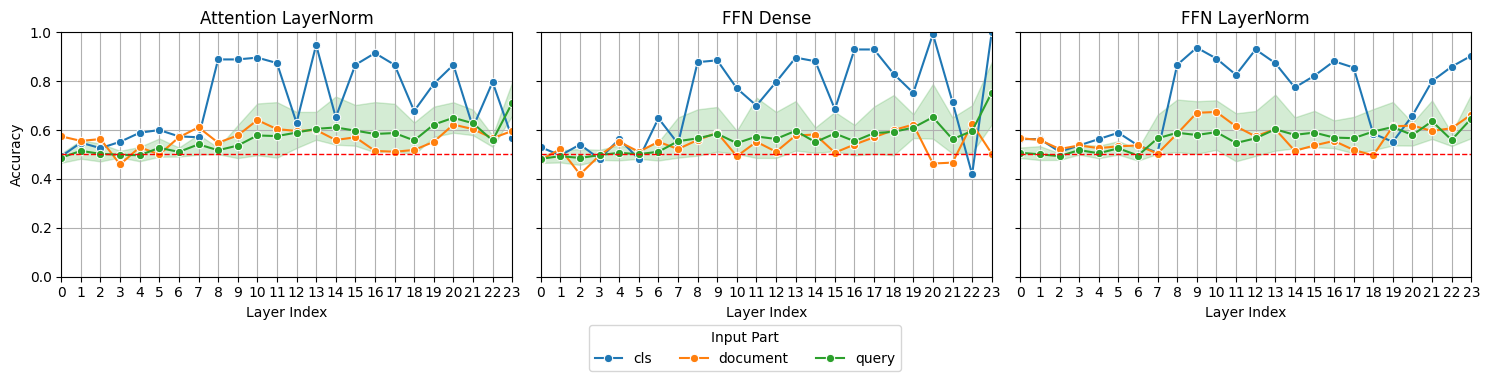

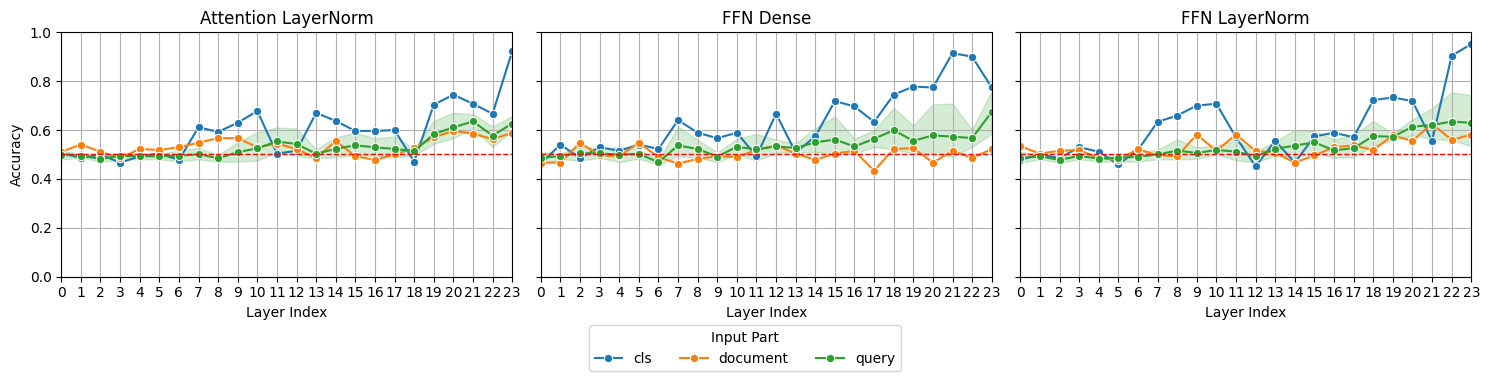

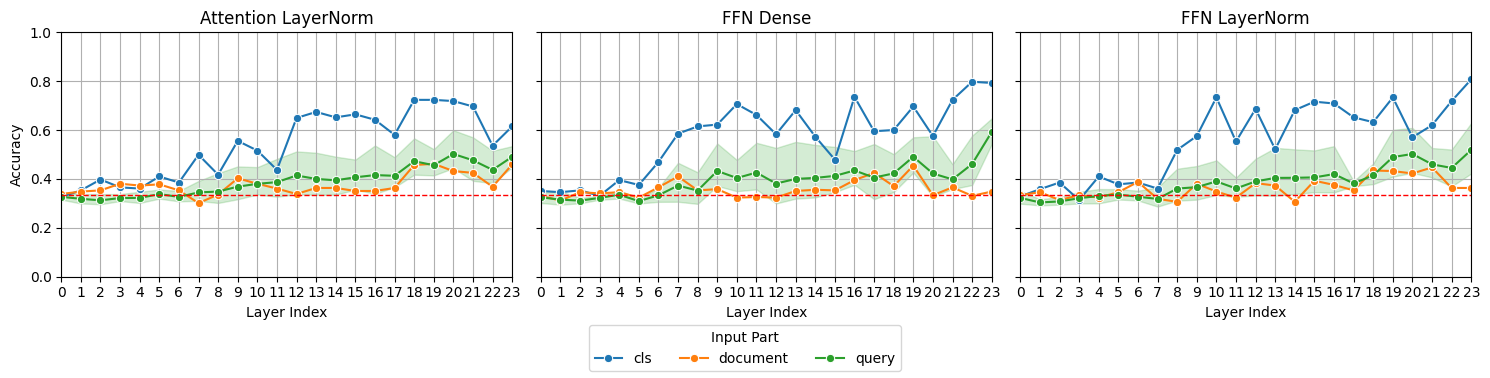

monobert_ood


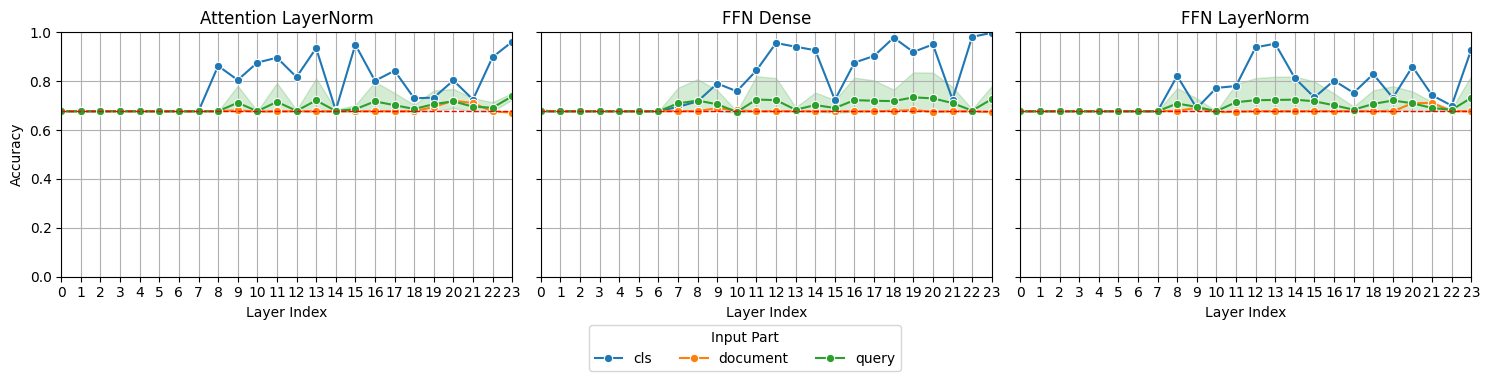

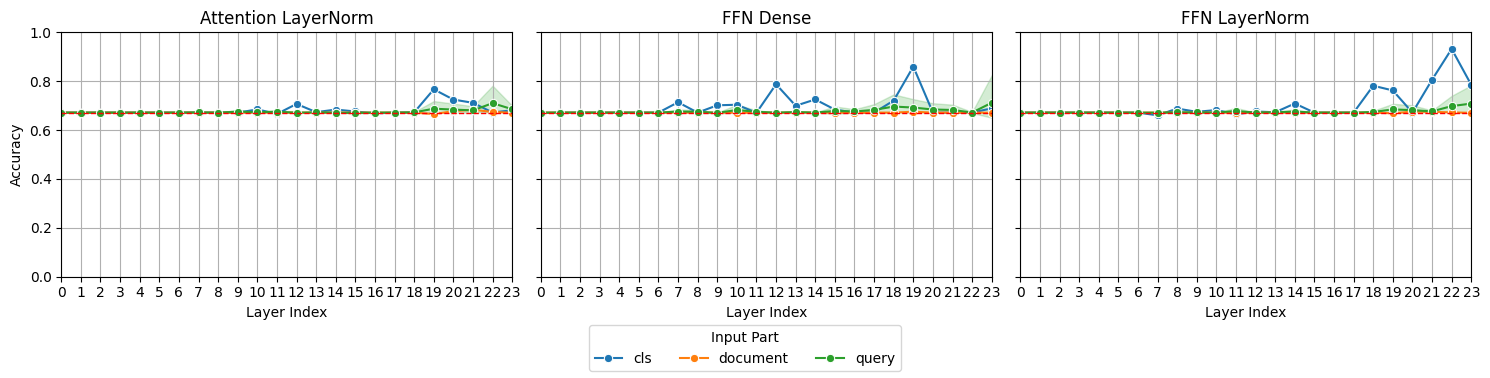

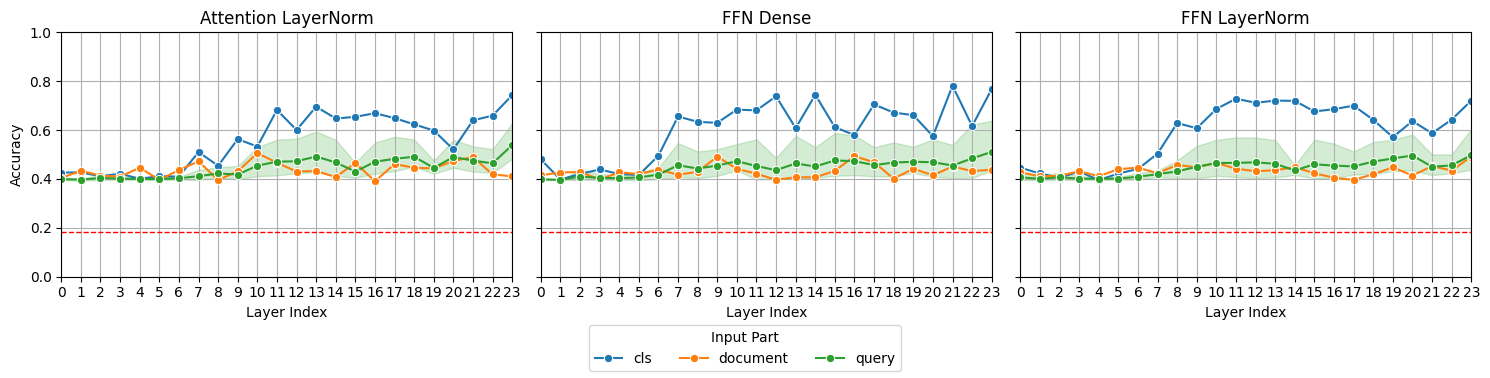

monobert_all


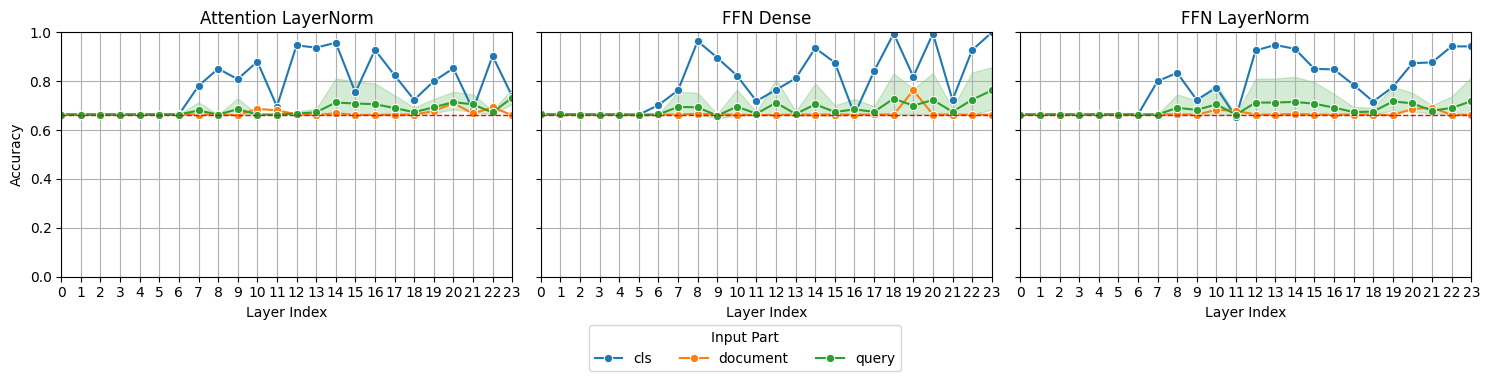

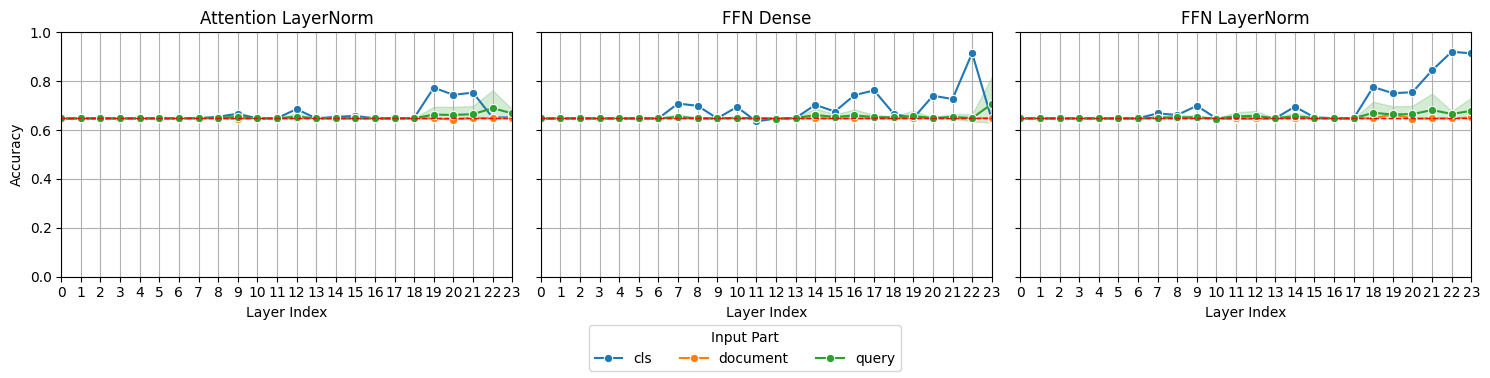

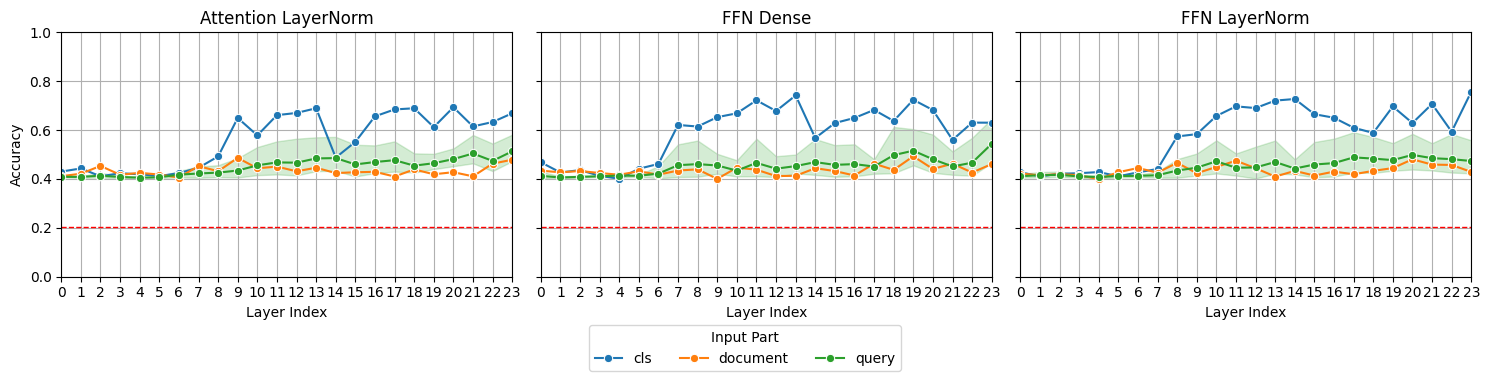

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

configuration_to_path = {
    "monobert_msmarco": "/home/vast/target_dir/relevance-integrations/jobs/src.evd.lda_xp.aggregateclassificationresults/cf9ab54f77771255c0bd1d003f8940f876becf1231f7a1d325b7f90b4cf7be6a/classification_results/",
    "monobert_ood": "/home/vast/target_dir/relevance-integrations/jobs/src.evd.lda_xp.aggregateclassificationresults/aa4656718436a0f6cf8f3efc5361ae3ca8df4c8a0c76e028f40cb949e1a2da23/classification_results/",
    "monobert_all": "/home/vast/target_dir/relevance-integrations/jobs/src.evd.lda_xp.aggregateclassificationresults/ed1a0559b1c10a32f7ffceca42c23a500868900d5153c0b17d5857ea71a94d05/classification_results/",
}

translate_names = {
    "attention.output.LayerNorm": "Attention LayerNorm",
    "output.dense": "FFN Dense",
    "output.LayerNorm": "FFN LayerNorm",
}
model_parts = ["attention.output.LayerNorm", "output.dense", "output.LayerNorm"]

# Load CSV
for configuration, path in configuration_to_path.items():
    print(configuration)
    for negative_types in ["weak_negatives", "strong_negatives", "all"]:
        # Load document components
        df_path = f"{configuration_to_path[configuration]}/aggregated_{negative_types}.csv"
        df = pd.read_csv(df_path)

        # Extract layer number
        df['Layer_Num'] = df['Layer'].str.extract(r'layer_(\d+)').astype(int)
        df['Input part'] = df['Input part'].apply(lambda x: 'query' if re.match(r'query_\d+', x) else x) # Group by ModelPart, Layer_Num, and new Input part, then average accuracy
        df_query = df.groupby(['ModelPart', 'Layer_Num', 'Input part'])['Accuracy'].mean().reset_index()

        # From the Confusion matrix, retrieve the proportion of positives in the test set:
        cm_string = df['CM'].iloc[0]
        cm_flat = np.fromstring(cm_string.strip("[]"), dtype=int, sep=' ')
        if negative_types == "all":
            cm = cm_flat.reshape(3, 3)

            class_names = {0: "Weak negatives (-1)", 1: "Negatives (0)", 2: "Positives (1)"}
            true_counts = cm.sum(axis=1)
            total = cm.sum()
            proportion_positive = true_counts[2] / total
        else:
            cm = cm_flat.reshape(2, 2)

            class_names = {0: "Negatives (0 or -1)", 1: "Positives (1)"}
            true_counts = cm.sum(axis=1)
            total = cm.sum()
            proportion_positive = 1 -true_counts[1] / total

        # Plotting
        fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
        for idx, model_part in enumerate(model_parts):
            ax = axes[idx]
            df_filtered = df[df['ModelPart'] == model_part]

            sns.lineplot(
                data=df_filtered,
                x='Layer_Num',
                y='Accuracy',
                hue='Input part',
                marker='o',
                ax=ax,
            )
            
            ax.axhline(y=proportion_positive, color='red', linestyle='--', linewidth=1)
            
            ax.set_title(translate_names[model_part])
            ax.set_xlabel('Layer Index')
            if idx == 0:
                ax.set_ylabel('Accuracy')
            else:
                ax.set_ylabel('')
            ax.grid(True)
            ax.set_xticks(sorted(df_filtered['Layer_Num'].unique()))
            min_x = df_filtered['Layer_Num'].min()
            max_x = df_filtered['Layer_Num'].max()
            ax.set_xlim(min_x, max_x)
            ax.set_ylim(0, 1)

            ax.get_legend().remove()

        # Shared legend
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=len(labels), title='Input Part')
        plt.tight_layout(rect=[0, 0.1, 1, 0.95])
        plt.savefig(f"./images/{configuration}_{negative_types}_accuracy.pdf", bbox_inches='tight', format='pdf')
        plt.show()